In [ ]:
# PRCP-1006:Home LoanDef Prediction
# ------------------------------------------
# Full notebook with EDA, preprocessing, model training & evaluation


In [ ]:
# Step 1: Import Libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")



In [ ]:
# STEP 2: Load All 7 Datasets

In [2]:
app = pd.read_csv("application_train.csv")
bureau = pd.read_csv("bureau.csv")
bureau_balance = pd.read_csv("bureau_balance.csv")
previous = pd.read_csv("previous_application.csv")
pos = pd.read_csv("POS_CASH_balance.csv")
credit_card = pd.read_csv("credit_card_balance.csv")
installments = pd.read_csv("installments_payments.csv")



In [3]:
app


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
app.shape

(307511, 122)

In [5]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [7]:
app.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [8]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [9]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [10]:
previous.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
pos.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [12]:
credit_card.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [13]:
installments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [ ]:
# Merge all datasets properly

In [ ]:
# STEP 3: Aggregate bureau_balance → Merge into bureau

In [ ]:
bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': 'count'
}).reset_index()

bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

In [ ]:
#STEP 4: Aggregate bureau → Merge into app

In [15]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',
    'AMT_CREDIT_SUM': 'sum',
    'AMT_CREDIT_SUM_DEBT': 'sum',
    'MONTHS_BALANCE': 'mean'
}).reset_index()

bureau_agg.columns = [
    'SK_ID_CURR',
    'BUREAU_LOAN_COUNT',
    'TOTAL_BUREAU_CREDIT',
    'TOTAL_BUREAU_DEBT',
    'AVG_BUREAU_MONTHS'
]

app = app.merge(bureau_agg, on='SK_ID_CURR', how='left')


In [ ]:
# STEP 5: Aggregate previous_application

In [16]:
prev_agg = previous.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_APPLICATION': 'mean',
    'AMT_CREDIT': 'mean'
}).reset_index()

prev_agg.columns = [
    'SK_ID_CURR',
    'PREV_APP_COUNT',
    'AVG_PREV_APP',
    'AVG_PREV_CREDIT'
]

app = app.merge(prev_agg, on='SK_ID_CURR', how='left')


In [ ]:
# STEP 6: Aggregate POS_CASH_balance

In [17]:
pos_agg = pos.groupby('SK_ID_CURR').agg({
    'SK_DPD': 'mean',
    'SK_DPD_DEF': 'mean'
}).reset_index()

pos_agg.columns = [
    'SK_ID_CURR',
    'POS_AVG_DPD',
    'POS_AVG_DPD_DEF'
]

app = app.merge(pos_agg, on='SK_ID_CURR', how='left')


In [ ]:
# STEP 7: Aggregate credit_card_balance

In [18]:
cc_agg = credit_card.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': 'mean',
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean',
    'SK_DPD': 'mean'
}).reset_index()

cc_agg.columns = [
    'SK_ID_CURR',
    'CC_AVG_BALANCE',
    'CC_AVG_LIMIT',
    'CC_AVG_DPD'
]

app = app.merge(cc_agg, on='SK_ID_CURR', how='left')


In [ ]:
# STEP 8: Aggregate installments_payments

In [19]:
ins_agg = installments.groupby('SK_ID_CURR').agg({
    'AMT_PAYMENT': 'mean',
    'AMT_INSTALMENT': 'mean',
    'DAYS_ENTRY_PAYMENT': 'mean'
}).reset_index()

ins_agg.columns = [
    'SK_ID_CURR',
    'AVG_PAYMENT',
    'AVG_INSTALMENT',
    'AVG_PAYMENT_DELAY'
]

app = app.merge(ins_agg, on='SK_ID_CURR', how='left')


In [20]:
app.shape

(307511, 137)

In [21]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 137 entries, SK_ID_CURR to AVG_PAYMENT_DELAY
dtypes: float64(80), int64(41), object(16)
memory usage: 321.4+ MB


In [ ]:
# STEP 9: Check Missing Values AFTER MERGING

In [22]:
missing = app.isnull().mean() * 100
missing = missing.sort_values(ascending=False)

missing.head(20)


CC_AVG_DPD                  71.739222
CC_AVG_LIMIT                71.739222
CC_AVG_BALANCE              71.739222
AVG_BUREAU_MONTHS           70.007252
COMMONAREA_AVG              69.872297
COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
dtype: float64

In [ ]:
# STEP 10: Handle Missing Values

In [23]:
# Drop Columns With Too Many Nulls

drop_cols = missing[missing > 50].index
app.drop(columns=drop_cols, inplace=True)


In [24]:
app.shape

(307511, 92)

In [25]:
# Fill Remaining Null Values

for col in app.columns:
    if app[col].dtype == 'object':
        app[col].fillna(app[col].mode()[0], inplace=True)
    else:
        app[col].fillna(app[col].median(), inplace=True)


In [26]:
missing = app.isnull().mean() * 100
missing = missing.sort_values(ascending=False)

missing.head(20)


SK_ID_CURR                  0.0
FLAG_DOCUMENT_5             0.0
FLAG_DOCUMENT_14            0.0
FLAG_DOCUMENT_13            0.0
FLAG_DOCUMENT_12            0.0
FLAG_DOCUMENT_11            0.0
FLAG_DOCUMENT_10            0.0
FLAG_DOCUMENT_9             0.0
FLAG_DOCUMENT_8             0.0
FLAG_DOCUMENT_7             0.0
FLAG_DOCUMENT_6             0.0
FLAG_DOCUMENT_4             0.0
TARGET                      0.0
FLAG_DOCUMENT_3             0.0
FLAG_DOCUMENT_2             0.0
DAYS_LAST_PHONE_CHANGE      0.0
DEF_60_CNT_SOCIAL_CIRCLE    0.0
OBS_60_CNT_SOCIAL_CIRCLE    0.0
DEF_30_CNT_SOCIAL_CIRCLE    0.0
OBS_30_CNT_SOCIAL_CIRCLE    0.0
dtype: float64

In [ ]:
# STEP 11: Encoding

In [27]:
app = pd.get_dummies(app, drop_first=True)


In [ ]:
# STEP 12: Basic EDA

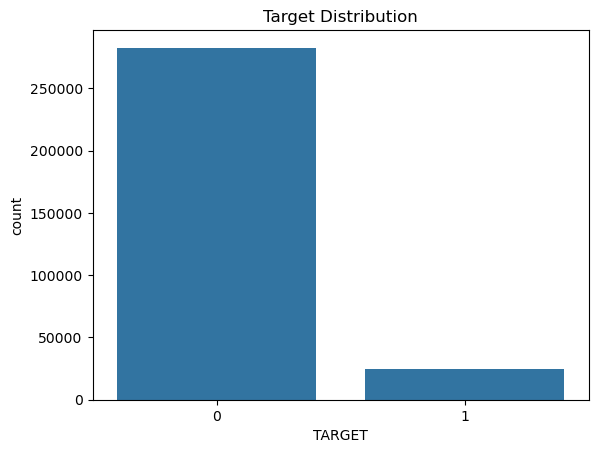

In [28]:
sns.countplot(x='TARGET', data=app)
plt.title("Target Distribution")
plt.show()


In [ ]:
# STEP 13: Feature Engineering

In [29]:
app['CREDIT_INCOME_RATIO'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
app['DEBT_CREDIT_RATIO'] = app['TOTAL_BUREAU_DEBT'] / (app['TOTAL_BUREAU_CREDIT'] + 1)


In [ ]:
# STEP 14: Prepare Data for Modeling

In [30]:
X = app.drop('TARGET', axis=1)
y = app['TARGET']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# STEP 15: Train Multiple Models

In [31]:
class_weight='balanced'

In [32]:
# Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

log_model.fit(X_train, y_train)
log_prob = log_model.predict_proba(X_test)[:,1]

log_auc = roc_auc_score(y_test, log_prob)
print("Logistic ROC-AUC:", log_auc)


Logistic ROC-AUC: 0.6239151616232443


In [33]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)
print("Random Forest ROC-AUC:", rf_auc)


Random Forest ROC-AUC: 0.7396876832510798


In [34]:
# XGBoost
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(y_test, xgb_prob)
print("XGBoost ROC-AUC:", xgb_auc)


XGBoost ROC-AUC: 0.7609628537403765


In [35]:
# Remove special characters from column names
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)


In [36]:
# LightGBM
lgbm = LGBMClassifier(
    class_weight='balanced',
    n_estimators=400,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)
lgb_prob = lgbm.predict_proba(X_test)[:,1]

lgb_auc = roc_auc_score(y_test, lgb_prob)
print("LightGBM ROC-AUC:", lgb_auc)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7410
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 183
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM ROC-AUC: 0.7645477948027505


In [37]:
features = X_train.columns

In [38]:
features.shape

(193,)

In [ ]:
# STEP 16: Model Comparison

In [39]:

results = pd.DataFrame({
    'Model': ['Logistic', 'Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC': [log_auc, rf_auc, xgb_auc, lgb_auc]
})

results.sort_values(by='ROC-AUC', ascending=False)



,Model,ROC-AUC
3,LightGBM,0.764548
2,XGBoost,0.760963
1,Random Forest,0.739688
0,Logistic,0.623915


In [ ]:
# Step 17: Feature Importance (LightGBM)

In [40]:
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_imp.head(10)


,Feature,Importance
27,EXT_SOURCE_2,614
28,EXT_SOURCE_3,606
7,DAYS_BIRTH,553
4,AMT_ANNUITY,496
77,AVG_PAYMENT_DELAY,483
3,AMT_CREDIT,448
8,DAYS_EMPLOYED,430
75,AVG_PAYMENT,390
191,CREDIT_INCOME_RATIO,369
10,DAYS_ID_PUBLISH,369


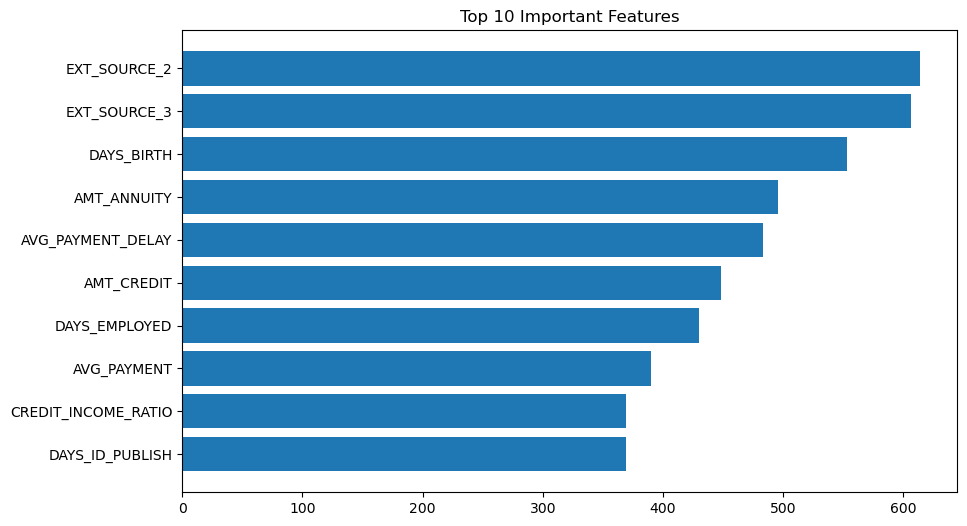

In [41]:
plt.figure(figsize=(10,6))
plt.barh(feature_imp['Feature'][:10], feature_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()



In [ ]:
# step 18: Customer Segmentation Logic (New Professional Section)

In [42]:
X_test['Default_Probability'] = lgb_prob

def risk_segment(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Medium Risk"
    else:
        return "High Risk"

X_test['Risk_Segment'] = X_test['Default_Probability'].apply(risk_segment)

X_test['Risk_Segment'].value_counts()


Risk_Segment
Medium Risk    25114
Low Risk       24905
High Risk      11484
Name: count, dtype: int64

In [43]:
lgb_prob = lgbm.predict_proba(X_test[features])[:,1]


In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [ ]:
# Draw roc curve graph

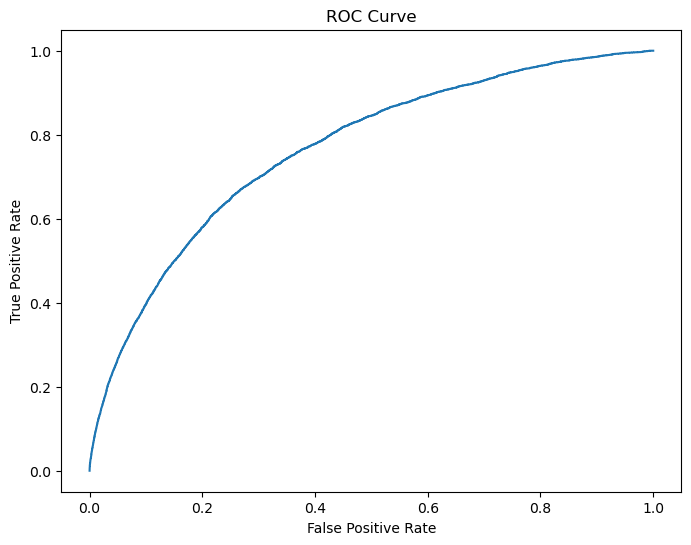

In [45]:
fpr, tpr, thresholds = roc_curve(y_test, lgb_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
# Optimal Threshold (Youden’s J Method)

In [46]:
# Calculate Youden’s J statistic
J = tpr - fpr

# Find index of maximum J
ix = np.argmax(J)

best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

Best Threshold: 0.4985944441905345


In [47]:
# Best Threshold
y_pred_best = (lgb_prob >= best_threshold).astype(int)

In [48]:
y_pred_best


array([0, 0, 1, ..., 0, 1, 1])

In [ ]:
# Confusion Matrix

In [49]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Confusion Matrix:
 [[41463 15075]
 [ 1646  3319]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.67      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



In [50]:
# Approval Rate Calculate
approval_rate = (y_pred_best == 0).mean()

print("Approval Rate:", approval_rate)

Approval Rate: 0.700925158122368


In [51]:
# Default Capture Rate

default_capture = cm[1,1] / (cm[1,0] + cm[1,1])

print("Default Detection Rate:", default_capture)

Default Detection Rate: 0.668479355488419


In [54]:
# Add probabilities
valid_data = X_test.copy()
valid_data["default_probability"] = y_pred_best

# Approved customers (70%)
approved_customers = valid_data[valid_data["default_probability"] < best_threshold]

# Rejected customers (30%)
rejected_customers = valid_data[valid_data["default_probability"] >= best_threshold]

print("Approved:", approved_customers.shape[0])
print("Rejected:", rejected_customers.shape[0])

Approved: 43109
Rejected: 18394


In [ ]:
# Save Model

In [ ]:
pip install joblib

In [ ]:
import joblib

joblib.dump(model, "loan_default_model.pkl")

In [ ]:
model.predict(X_new)